# **Aprendizaje Automático I - 2025**
## Entregable 2do Parcial

### Integrantes Grupo 4:
- Juan Ignacio Centanaro
- Rocio Daniela Giménez
- Agustín Gleria
- Joel Matias Silva
- Walter Sebastian Vdovichenko
- Yamil Vogel Dumit


---
## Análisis GDP Provincias Argentina
- **Objetivo:** Predecir PBI basado en pobreza y deserción escolar
- *Lo que esperamos encontrar:*
    - Coeficiente de poverty: Probablemente negativo (a mayor pobreza, menor GDP)
    - Coeficiente de school_dropout: Probablemente negativo (a mayor deserción, menor GDP)


---
## INICIO
---

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

import warnings

In [ ]:
warnings.filterwarnings('ignore')
plt.style.use('default')
sns.set_palette("deep")

---
### Load + EDA

In [ ]:
df = pd.read_excel('Tabla_GDP_1parcial.xlsx')

In [ ]:
df.describe()

,gdp,illiteracy,poverty,deficient_infra,school_dropout,no_healthcare,birth_mortal,pop,movie_theatres_per_cap,doctors_per_cap
count,2.000000e+01,20.000000,22.000000,22.000000,20.000000,20.000000,22.000000,2.200000e+01,22.000000,22.000000
mean,3.277525e+07,3.166403,9.925625,12.677304,1.749807,50.391715,4.986364,1.686352e+06,0.000007,0.004894
std,6.456121e+07,1.847379,3.779530,7.216860,1.201194,9.374135,3.498339,3.219828e+06,0.000004,0.001522
min,3.807057e+06,0.791485,3.398774,3.839852,0.204093,29.232100,0.800000,2.739640e+05,0.000002,0.002821
25%,8.188735e+06,1.967893,7.472754,7.569677,0.754950,45.368700,3.025000,5.143715e+05,0.000004,0.004061
50%,1.172229e+07,2.743675,9.142440,10.865881,1.437767,49.370500,4.000000,7.775305e+05,0.000006,0.004757
75%,2.119858e+07,3.517830,12.500143,16.100647,2.651142,55.079600,5.875000,1.230606e+06,0.000009,0.005334
max,2.926899e+08,7.517580,17.035583,31.479527,3.864265,65.812600,16.200000,1.562508e+07,0.000019,0.010175


In [ ]:
print("Ejemplos al azar:")
df.sample(5, random_state=42)

Ejemplos al azar:


,province,gdp,illiteracy,poverty,deficient_infra,school_dropout,no_healthcare,birth_mortal,pop,movie_theatres_per_cap,doctors_per_cap
0,Buenos Aires,2.926899e+08,1.38324,8.167798,5.511856,0.766168,48.7947,4.4,15625084,0.000006,0.004836
13,Neuquén,2.256411e+07,1.94375,9.456635,11.267278,1.393504,48.7431,3.3,551266,0.000009,0.005067
8,Jujuy,NaN,2.15139,13.367965,12.483179,0.721295,54.1615,3.7,673307,0.000003,0.003958
1,Catamarca,6.150949e+06,2.34414,9.234095,10.464484,0.951963,45.0456,1.5,367828,0.000005,0.004502
15,Salta,1.343883e+07,3.34609,16.870500,14.182303,1.482030,NaN,5.8,1214441,0.000004,0.003991


---
- **Valores Nulos**
    - Estrategia de imputación:
    - GDP: usar la mediana (menos sensible a outliers)
    - school_dropout: usar la media (pocos valores nulos)

In [ ]:
# Verificar valores nulos
print("\nValores nulos por columna:")
print(df.isnull().sum())

# Verificar duplicados
print(f"\nFilas duplicadas: {df.duplicated().sum()}")


Valores nulos por columna:
province                  0
gdp                       2
illiteracy                2
poverty                   0
deficient_infra           0
school_dropout            2
no_healthcare             2
birth_mortal              0
pop                       0
movie_theatres_per_cap    0
doctors_per_cap           0
dtype: int64

Filas duplicadas: 0


Valores nulos antes de la limpieza:
province                  0
gdp                       2
illiteracy                2
poverty                   0
deficient_infra           0
school_dropout            2
no_healthcare             2
birth_mortal              0
pop                       0
movie_theatres_per_cap    0
doctors_per_cap           0
dtype: int64

Valores nulos después de la limpieza:
province                  0
gdp                       0
illiteracy                2
poverty                   0
deficient_infra           0
school_dropout            0
no_healthcare             2
birth_mortal              0
pop                       0
movie_theatres_per_cap    0
doctors_per_cap           0
dtype: int64


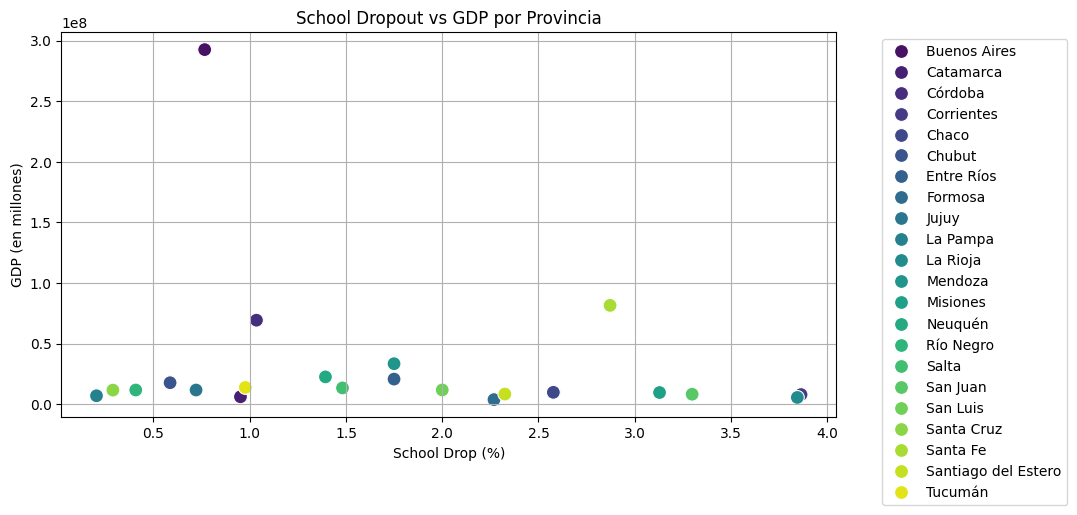

In [ ]:
df_clean = df.copy()

print("Valores nulos antes de la limpieza:")
print("=" * 40)
print(df_clean.isnull().sum())

from sklearn.impute import SimpleImputer

# Imputar GDP con mediana
gdp_imputer = SimpleImputer(strategy='median') # Usar mediana para evitar influencia de outliers
df_clean['gdp'] = gdp_imputer.fit_transform(df_clean[['gdp']]).ravel()

# Imputar school_dropout con media
dropout_imputer = SimpleImputer(strategy='mean')
df_clean['school_dropout'] = dropout_imputer.fit_transform(df_clean[['school_dropout']]).ravel()

print("\nValores nulos después de la limpieza:")
print("=" * 40)
print(df_clean.isnull().sum())

# Grafico: school_dropout vs GDP por provincia
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df_clean, x='school_dropout', y='gdp', hue='province', palette='viridis', s=100)
plt.title('School Dropout vs GDP por Provincia')
plt.xlabel('School Drop (%)')
plt.ylabel('GDP (en millones)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.show()

In [ ]:
# Outliers: GDP
gdp_q1 = df_clean['gdp'].quantile(0.25)
gdp_q3 = df_clean['gdp'].quantile(0.75)
gdp_iqr = gdp_q3 - gdp_q1
gdp_lower_bound = gdp_q1 - 1.5 * gdp_iqr
gdp_upper_bound = gdp_q3 + 1.5 * gdp_iqr
outliers_gdp = df_clean[(df_clean['gdp'] < gdp_lower_bound) | (df_clean['gdp'] > gdp_upper_bound)]
print(f"\nOutliers en GDP: {len(outliers_gdp)} filas")

# Outliers: school_dropout
dropout_q1 = df_clean['school_dropout'].quantile(0.25)
dropout_q3 = df_clean['school_dropout'].quantile(0.75)
dropout_iqr = dropout_q3 - dropout_q1
dropout_lower_bound = dropout_q1 - 1.5 * dropout_iqr
dropout_upper_bound = dropout_q3 + 1.5 * dropout_iqr
outliers_dropout = df_clean[(df_clean['school_dropout'] < dropout_lower_bound) | (df_clean['school_dropout'] > dropout_upper_bound)]
print(f"Outliers en School Dropout: {len(outliers_dropout)} filas")

# outliers: poverty
poverty_q1 = df_clean['poverty'].quantile(0.25)
poverty_q3 = df_clean['poverty'].quantile(0.75)
poverty_iqr = poverty_q3 - poverty_q1
poverty_lower_bound = poverty_q1 - 1.5 * poverty_iqr
poverty_upper_bound = poverty_q3 + 1.5 * poverty_iqr
outliers_poverty = df_clean[(df_clean['poverty'] < poverty_lower_bound) | (df_clean['poverty'] > poverty_upper_bound)]
print(f"Outliers en Poverty Rate: {len(outliers_poverty)} filas")


Outliers en GDP: 3 filas
Outliers en School Dropout: 0 filas
Outliers en Poverty Rate: 0 filas


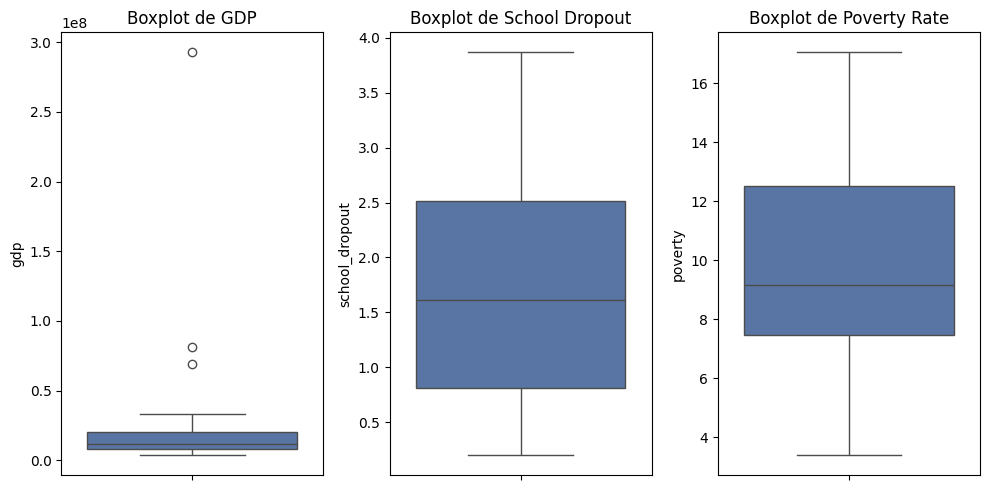

In [ ]:
# Boxplot para GDP, School Dropout y Poverty Rate
plt.figure(figsize=(10, 5))
plt.subplot(1, 3, 1)
sns.boxplot(data=df_clean, y='gdp')
plt.title('Boxplot de GDP')
plt.subplot(1, 3, 2)
sns.boxplot(data=df_clean, y='school_dropout')
plt.title('Boxplot de School Dropout')
plt.subplot(1, 3, 3)
sns.boxplot(data=df_clean, y='poverty')
plt.title('Boxplot de Poverty Rate')
plt.tight_layout()
plt.show()

---
### Analisis de Correlaciones


Matriz de correlación:
                     gdp   poverty  school_dropout
gdp             1.000000 -0.245279       -0.186959
poverty        -0.245279  1.000000        0.353989
school_dropout -0.186959  0.353989        1.000000


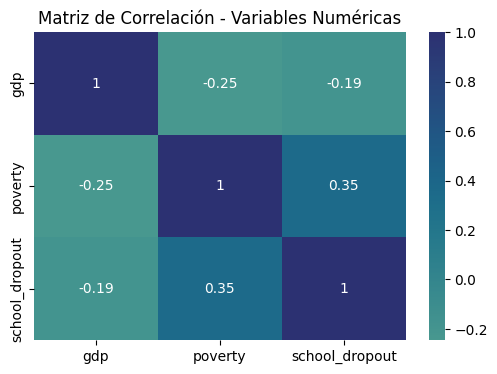

In [ ]:
# Matriz de correlación
correlation_matrix = df_clean[['gdp', 'poverty', 'school_dropout']].corr()
print("\nMatriz de correlación:")
print(correlation_matrix)

# Visualización de correlaciones
plt.figure(figsize=(6, 4))
sns.heatmap(correlation_matrix, annot=True, cmap='crest', center=0)
plt.title('Matriz de Correlación - Variables Numéricas')
plt.show()

---
### Definicion de Variables

In [ ]:
# Definir variables independientes (X) y dependiente (y)
# Objetivo: predecir 'gdp' usando 'poverty' y 'school_dropout'
X = df_clean[['poverty', 'school_dropout']]
y = df_clean['gdp']

print(f"Variables independientes (X): {list(X.columns)}")
print(f"Variable dependiente (y): {y.name}")
print(f"Forma de X: {X.shape}")
print(f"Forma de y: {y.shape}")

Variables independientes (X): ['poverty', 'school_dropout']
Variable dependiente (y): gdp
Forma de X: (22, 2)
Forma de y: (22,)


---
### Conjustos Train y Test

In [ ]:
# Split 80/20 con random_state=123
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=123
)

print(f"Tamaño del conjunto de entrenamiento: {X_train.shape[0]} filas")
print(f"Tamaño del conjunto de prueba: {X_test.shape[0]} filas")
print(f"Porcentaje train: {X_train.shape[0]/len(df_clean)*100:.1f}%")
print(f"Porcentaje test: {X_test.shape[0]/len(df_clean)*100:.1f}%")

Tamaño del conjunto de entrenamiento: 17 filas
Tamaño del conjunto de prueba: 5 filas
Porcentaje train: 77.3%
Porcentaje test: 22.7%


---
### Normalización de las Variables


In [ ]:
# Analizar las escalas antes de normalizar
print("Escalas originales:")
print(f"GDP - Media: {y_train.mean():,.0f}, Std: {y_train.std():,.0f}")
print(f"Poverty - Media: {X_train['poverty'].mean():.2f}, Std: {X_train['poverty'].std():.2f}")
print(f"School_dropout - Media: {X_train['school_dropout'].mean():.2f}, Std: {X_train['school_dropout'].std():.2f}")

# Normalizar las variables independientes (X)
# IMPORTANTE: Solo ajustar en train, aplicar en test para evitar data leakage
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# Convertir de vuelta a DataFrame para mantener nombres de columnas
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

# También normalizar y (GDP) para mejor comparación
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1)).ravel()

print("\nEscalas después de normalización (variables X):")
print(f"Poverty - Media: {X_train_scaled['poverty'].mean():.6f}, Std: {X_train_scaled['poverty'].std():.6f}")
print(f"School_dropout - Media: {X_train_scaled['school_dropout'].mean():.6f}, Std: {X_train_scaled['school_dropout'].std():.6f}")

print(f"\nGDP normalizado - Media: {y_train_scaled.mean():.6f}, Std: {y_train_scaled.std():.6f}")

X_train = X_train_scaled.copy()
X_test = X_test_scaled.copy()
y_train = y_train_scaled.copy()
y_test = y_test_scaled.copy()


Escalas originales:
GDP - Media: 32,823,848, Std: 68,689,416
Poverty - Media: 9.33, Std: 3.37
School_dropout - Media: 1.55, Std: 1.08

Escalas después de normalización (variables X):
Poverty - Media: -0.000000, Std: 1.030776
School_dropout - Media: -0.000000, Std: 1.030776

GDP normalizado - Media: 0.000000, Std: 1.000000


---
---
# Regresión Lineal
- Entrenamiento del modelo

In [ ]:
print("\n=== Resultados ===\n")

# Crear y entrenar el modelo de regresión lineal
model = LinearRegression()
model.fit(X_train, y_train)

print(f"Intercepto (β₀): {model.intercept_:.6f}")
print("Coeficientes (β₁, β₂):")
for i, coef in enumerate(model.coef_):
    print(f"  {X.columns[i]}: {coef:.6f}")

# Ecuación del modelo
print(f"\nEcuación del modelo:")
print(f"gdp = {model.intercept_:.6f} + ({model.coef_[0]:.6f} * poverty) + ({model.coef_[1]:.6f} * school_dropout)")



=== Resultados ===

Intercepto (β₀): -0.000000
Coeficientes (β₁, β₂):
  poverty: -0.113423
  school_dropout: -0.186718

Ecuación del modelo:
gdp = -0.000000 + (-0.113423 * poverty) + (-0.186718 * school_dropout)


In [ ]:
print("\n=== Resultados ===\n")

# Crear y entrenar el modelo de regresión lineal
model = LinearRegression()
model.fit(X_train, y_train)

print(f"Intercepto (β₀): {model.intercept_:.6f}")
print("Coeficientes (β₁, β₂):")
for i, coef in enumerate(model.coef_):
    print(f"  {X.columns[i]}: {coef:.6f}")

# Ecuación del modelo
print(f"\nEcuación del modelo:")
print(f"gdp = {model.intercept_:.6f} + ({model.coef_[0]:.6f} * poverty) + ({model.coef_[1]:.6f} * school_dropout)")



=== Resultados ===

Intercepto (β₀): -0.000000
Coeficientes (β₁, β₂):
  poverty: -0.113423
  school_dropout: -0.186718

Ecuación del modelo:
gdp = -0.000000 + (-0.113423 * poverty) + (-0.186718 * school_dropout)


---
### Predicciones

In [ ]:
print("\n=== Resultados de las Predicciones ===")

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

print(f"Shape de Train: {y_train_pred.shape}")
print(f"Shape de Test: {y_test_pred.shape}")

print("\nPrimeras 5 predicciones vs valores reales (conjunto de prueba):")
comparison_df = pd.DataFrame({
    'Real': y_test,
    'Predicción': y_test_pred,
    'Diferencia': y_test - y_test_pred
})
comparison_df.head()


=== Resultados de las Predicciones ===
Shape de Train: (17,)
Shape de Test: (5,)

Primeras 5 predicciones vs valores reales (conjunto de prueba):


,Real,Predicción,Diferencia
0,-0.345014,-0.409809,0.064795
1,-0.435436,-0.395546,-0.039890
2,-0.226235,0.215653,-0.441888
3,0.731782,-0.123093,0.854875
4,-0.372995,-0.530938,0.157943


---
### Evaluación del Modelo

In [ ]:
# Calcular métricas sobre el conjunto train y test

train_mae = mean_absolute_error(y_train, y_train_pred)
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train, y_train_pred)

test_mae = mean_absolute_error(y_test, y_test_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, y_test_pred)

print("MÉTRICAS DE RENDIMIENTO:")
print("=" * 50)
print(f"{'Métrica':<10} {'Entrenamiento':<25} {'Prueba':<15}")
print("-" * 50)
print(f"{'MAE':<10} {train_mae:<25.4f} {test_mae:<15.4f}")
print(f"{'MSE':<10} {train_mse:<25.4f} {test_mse:<15.4f}")
print(f"{'RMSE':<10} {train_rmse:<25.4f} {test_rmse:<15.4f}")
print(f"{'R²':<10} {train_r2:<25.4f} {test_r2:<15.4f}") # Si el valor obtenido es negativo, significa que el modelo es peor que predecir la media.

# Interpretación del R²
print(f"\nINTERPRETACIÓN:")
print(f"- El modelo explica {test_r2*100:.1f}% de la variabilidad en el gdp")
print(f"- Error promedio absoluto: {test_mae:.2f} puntos porcentuales de gdp")
print(f"- RMSE: {test_rmse:.2f} (penaliza más los errores grandes)")
print(f"- El modelo es {100 - test_r2*100:.1f}% menos preciso que predecir la media de gdp")

MÉTRICAS DE RENDIMIENTO:
Métrica    Entrenamiento             Prueba         
--------------------------------------------------
MAE        0.4910                    0.3119         
MSE        0.9395                    0.1914         
RMSE       0.9693                    0.4374         
R²         0.0605                    -0.0066        

INTERPRETACIÓN:
- El modelo explica -0.7% de la variabilidad en el gdp
- Error promedio absoluto: 0.31 puntos porcentuales de gdp
- RMSE: 0.44 (penaliza más los errores grandes)
- El modelo es 100.7% menos preciso que predecir la media de gdp


---
### Visualizaciones

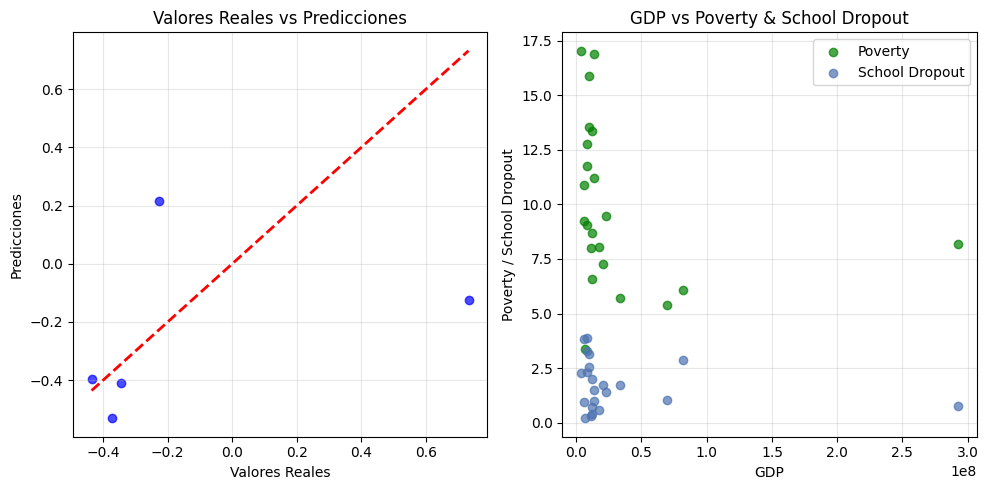

In [ ]:
# Crear subplots
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# 0. Valores reales vs predicciones
axes[0].scatter(y_test, y_test_pred, alpha=0.7, color='blue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Valores Reales')
axes[0].set_ylabel('Predicciones')
axes[0].set_title('Valores Reales vs Predicciones')
axes[0].grid(True, alpha=0.3)

# 4. GDP vs Poverty & School Dropout
axes[1].scatter(df_clean['gdp'], df_clean['poverty'], alpha=0.7, color='green', label='Poverty')
axes[1].scatter(df_clean['gdp'], df_clean['school_dropout'], alpha=0.7, label='School Dropout')
axes[1].set_xlabel('GDP')
axes[1].set_ylabel('Poverty / School Dropout')
axes[1].set_title('GDP vs Poverty & School Dropout')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

# Test vs Dummy

**Un R² negativo significa que nuestro modelo es peor que simplemente predecir siempre la media de los valores reales.**

Problemas con los datos:

1. Datos de entrenamiento y prueba muy diferentes
2. Outliers extremos en el conjunto de prueba

In [ ]:
# Verificar las predicciones
print("Estadísticas de y_test:")
print(f"Media: {y_test.mean()}")
print(f"Std: {y_test.std()}")

print("\nEstadísticas de predicciones:")
print(f"Media: {y_test_pred.mean()}")
print(f"Std: {y_test_pred.std()}")

# Diagnóstico del modelo con Dummy Regressor
from sklearn.dummy import DummyRegressor
dummy = DummyRegressor(strategy='mean')
dummy.fit(X_train, y_train)
dummy_pred = dummy.predict(X_test)
dummy_r2 = r2_score(y_test, dummy_pred)
print(f"\nR² del modelo dummy (siempre media): {dummy_r2}")  # Debe ser 0

Estadísticas de y_test:
Media: -0.12957965699144158
Std: 0.43600373685176874

Estadísticas de predicciones:
Media: -0.24874650661286796
Std: 0.2677978740626108

R² del modelo dummy (siempre media): -0.08832694895397264


---
---
# Regresión Polinómica
- Modelo de Regresión Polinómica (grado 2 a 4)

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

poly_results = {}

# Usamos PolynomialFeatures para crear características polinómicas
for degree in range(2,6):
    poly = PolynomialFeatures(degree)
    X_poly = poly.fit_transform(X_train)
    model_poly = LinearRegression().fit(X_poly, y_train)
    y_poly_pred = model_poly.predict(X_poly)
    poly_results[degree] = {
        "model": model_poly,
        "X_poly": X_poly,
        "y_pred": y_poly_pred,
        "mae": mean_absolute_error(y_train, y_poly_pred),
        "mse": mean_squared_error(y_train, y_poly_pred),
        "r2": r2_score(y_train, y_poly_pred)
    }

---
### Analisis y Visualizaciones

🎯 Interpretación de los Gráficos:

💡 Buscamos que:
- MAE y MSE: Valores más bajos
- R²: Valores más altos (cerca de 1)
- En scatter: Puntos cerca de la línea roja

---

- Comparativa de Métricas

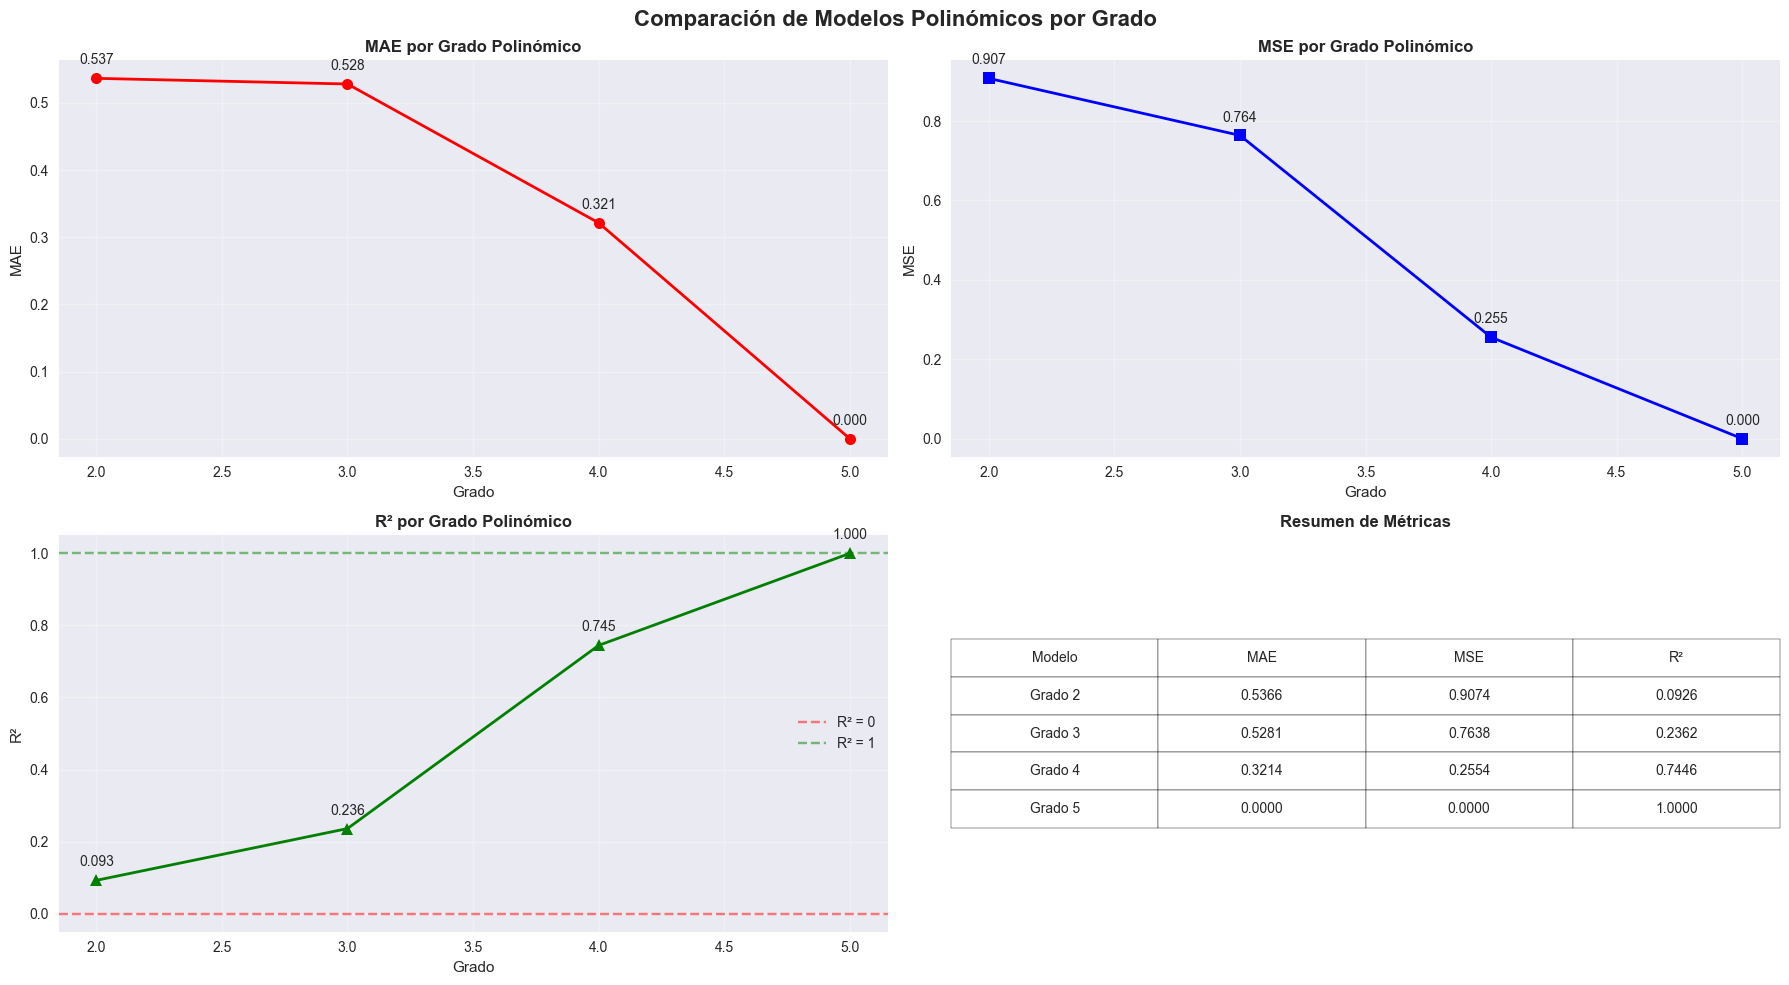

In [ ]:
import seaborn as sns
from matplotlib.patches import Rectangle

# Estilo del plot
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
fig.suptitle('Comparación de Modelos Polinómicos por Grado', fontsize=16, fontweight='bold')

# Preparar datos para los gráficos
degrees = list(poly_results.keys())
mae_values = [poly_results[d]['mae'] for d in degrees]
mse_values = [poly_results[d]['mse'] for d in degrees]
r2_values = [poly_results[d]['r2'] for d in degrees]

# MAE
axes[0,0].plot(degrees, mae_values, marker='o', linewidth=2, markersize=8, color='red')
axes[0,0].set_title('MAE por Grado Polinómico', fontweight='bold')
axes[0,0].set_xlabel('Grado')
axes[0,0].set_ylabel('MAE')
axes[0,0].grid(True, alpha=0.3)
for i, v in enumerate(mae_values):
    axes[0,0].annotate(f'{v:.3f}', (degrees[i], v), textcoords="offset points", xytext=(0,10), ha='center')

# MSE
axes[0,1].plot(degrees, mse_values, marker='s', linewidth=2, markersize=8, color='blue')
axes[0,1].set_title('MSE por Grado Polinómico', fontweight='bold')
axes[0,1].set_xlabel('Grado')
axes[0,1].set_ylabel('MSE')
axes[0,1].grid(True, alpha=0.3)
for i, v in enumerate(mse_values):
    axes[0,1].annotate(f'{v:.3f}', (degrees[i], v), textcoords="offset points", xytext=(0,10), ha='center')

# R²
axes[1,0].plot(degrees, r2_values, marker='^', linewidth=2, markersize=8, color='green')
axes[1,0].set_title('R² por Grado Polinómico', fontweight='bold')
axes[1,0].set_xlabel('Grado')
axes[1,0].set_ylabel('R²')
axes[1,0].grid(True, alpha=0.3)
axes[1,0].axhline(y=0, color='red', linestyle='--', alpha=0.5, label='R² = 0')
axes[1,0].axhline(y=1, color='green', linestyle='--', alpha=0.5, label='R² = 1')
axes[1,0].legend()
for i, v in enumerate(r2_values):
    axes[1,0].annotate(f'{v:.3f}', (degrees[i], v), textcoords="offset points", xytext=(0,10), ha='center')

# Tabla resumen
axes[1,1].axis('tight')
axes[1,1].axis('off')
table_data = []
for degree in degrees:
    table_data.append([
        f"Grado {degree}",
        f"{poly_results[degree]['mae']:.4f}",
        f"{poly_results[degree]['mse']:.4f}",
        f"{poly_results[degree]['r2']:.4f}"
    ])

table = axes[1,1].table(cellText=table_data,
                       colLabels=['Modelo', 'MAE', 'MSE', 'R²'],
                       cellLoc='center',
                       loc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)
axes[1,1].set_title('Resumen de Métricas', fontweight='bold')

plt.tight_layout()
plt.show()

- Predicciones VS Valores Reales

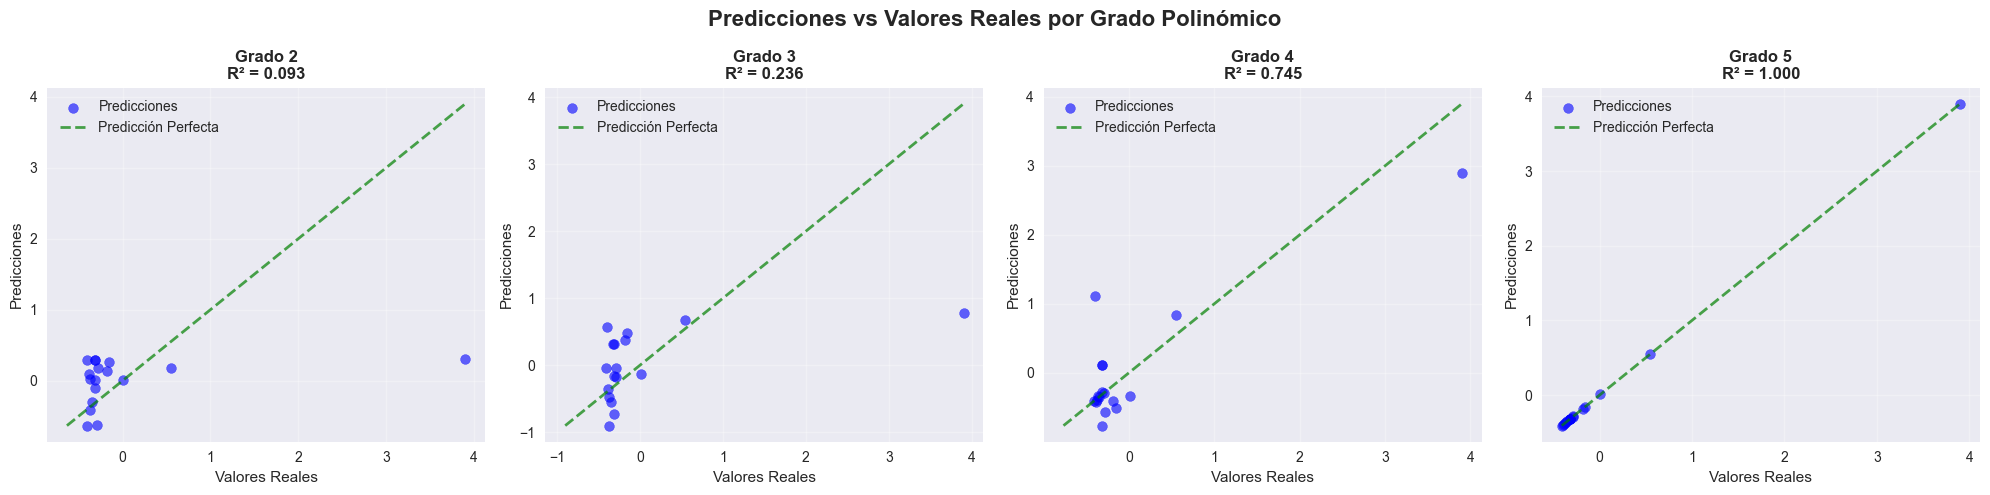

In [ ]:
fig, axes = plt.subplots(1, len(degrees), figsize=(5*len(degrees), 5))

if len(degrees) == 1:
    axes = [axes]

fig.suptitle('Predicciones vs Valores Reales por Grado Polinómico', fontsize=16, fontweight='bold')

for i, degree in enumerate(degrees):
    y_pred = poly_results[degree]['y_pred']

    # Scatter plot (usar y_train para que coincidan las longitudes)
    axes[i].scatter(y_train, y_pred, alpha=0.6, s=50, label='Predicciones', color='blue')

    # Línea perfecta (y = x)
    min_val = min(min(y_train), min(y_pred))
    max_val = max(max(y_train), max(y_pred))
    axes[i].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Predicción Perfecta', alpha=0.7, color='green')

    # Configuración
    axes[i].set_title(f'Grado {degree}\nR² = {poly_results[degree]["r2"]:.3f}', fontweight='bold')
    axes[i].set_xlabel('Valores Reales')
    axes[i].set_ylabel('Predicciones')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


---
---
# Clustering con K-Means

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [ ]:
# Imputar valores faltantes con mediana
imputer = SimpleImputer(strategy='median')
df_imputed = pd.DataFrame(imputer.fit_transform(df[['gdp','poverty','school_dropout']]),
                          columns=['gdp', 'poverty', 'school_dropout'])
df_imputed.insert(0, 'province', df['province'])

# Escalado de características
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_imputed[['gdp','poverty','school_dropout']])

- Metodo del Codo (para determinar el numero optimo de clusters)

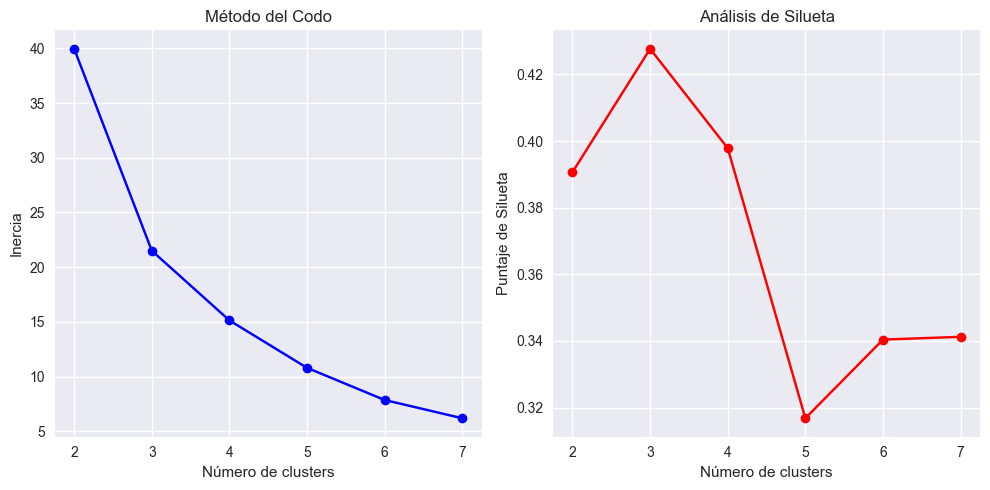

In [ ]:
# Metodo del Codo
inertias = []
sil_scores = []
k_range = range(2, 8)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Gráfico de método del codo
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(k_range, inertias, 'bo-')
plt.xlabel('Número de clusters')
plt.ylabel('Inercia')
plt.title('Método del Codo')

# Gráfico de silueta
plt.subplot(1, 2, 2)
plt.plot(k_range, sil_scores, 'ro-')
plt.xlabel('Número de clusters')
plt.ylabel('Puntaje de Silueta')
plt.title('Análisis de Silueta')
plt.tight_layout()
plt.show()

 - *Interpretación del Método del Codo:* Busca el 'codo' en el gráfico, donde la curva se dobla abruptamente. Ese punto sugiere un buen balance entre el número de clústeres y la inercia.
 - *Interpretacion del grafico de silueta:* el el valor de silueta más alto indica que los clústeres están bien separados y son compactos. Un valor cercano a 1 sugiere que los puntos están bien agrupados, mientras que valores cercanos a 0 indican que los clústeres se superponen. Valores negativos sugieren que los puntos podrían estar en el clúster equivocado.


In [ ]:
k_optimo = 3  # Elegimos el valor de k basado en el gráfico del codo
print(f"Número óptimo de clústeres (K): {k_optimo}")

Número óptimo de clústeres (K): 3


In [ ]:
# Clustering con KMeans
kmeans = KMeans(n_clusters= k_optimo, random_state=123)

# Escalar las variables para el clustering
scaler_for_clustering = StandardScaler()
X_for_clustering_scaled = scaler_for_clustering.fit_transform(df_clean[['poverty', 'school_dropout']])
X_for_clustering_scaled = pd.DataFrame(X_for_clustering_scaled, columns=['poverty', 'school_dropout'], index=df_clean.index)

clusters = kmeans.fit_predict(X_for_clustering_scaled)
df_imputed["cluster"] = clusters


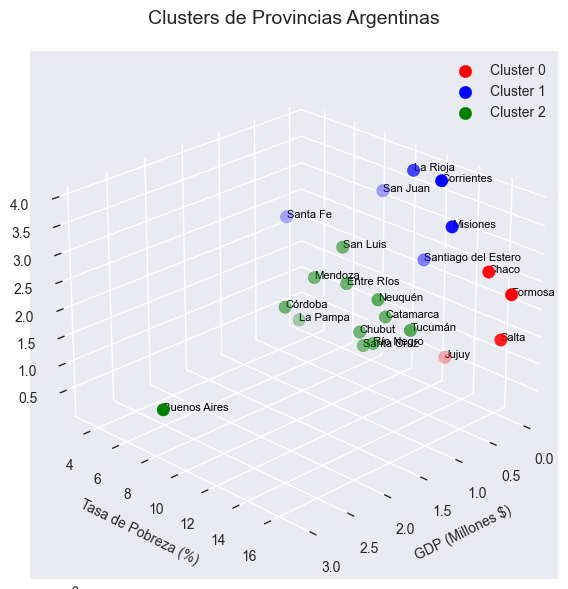

In [ ]:
# Visualización 3D de los clusters
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')

# Asignar colores a cada cluster
colors = ['red', 'blue', 'green', 'purple', 'orange', 'cyan']
cluster_names = [f'Cluster {i}' for i in range(k_optimo)]

# Graficar cada punto en 3D con su color de cluster
for i in range(k_optimo):
    cluster_data = df_imputed[df_imputed['cluster'] == i]
    ax.scatter(
        cluster_data['gdp'],
        cluster_data['poverty'],
        cluster_data['school_dropout'],
        s=80,  # Tamaño de los puntos
        c=colors[i],
        label=cluster_names[i],
        depthshade=True
    )

# Etiquetar cada punto con el nombre de la provincia
for i, row in df_imputed.iterrows():
    ax.text(
        row['gdp'],
        row['poverty'],
        row['school_dropout'],
        row['province'],
        size=8,
        zorder=1,
        color='black'
    )

# Configurar etiquetas de ejes
ax.set_xlabel('GDP (Millones $)', fontsize=10, labelpad=10)
ax.set_ylabel('Tasa de Pobreza (%)', fontsize=10, labelpad=10)
ax.set_zlabel('Deserción Escolar (%)', fontsize=10, labelpad=10)

# Título y leyenda
plt.title('Clusters de Provincias Argentinas', fontsize=14, pad=20)
ax.legend(fontsize=10)

# Ajustar la perspectiva de la visualización
ax.view_init(elev=25, azim=45)  # Elevación y ángulo

# Añadir grid para mejor orientación
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

- Analisis de  Clusteres

In [ ]:
print("\n=== Estadísticas Descriptivas por Clúster ===")
cluster_summary = df_imputed.groupby('cluster')[['poverty', 'school_dropout', 'gdp']].agg(['mean', 'median', 'std']).round(2)
cluster_summary.describe().T


=== Estadísticas Descriptivas por Clúster ===


count          mean           std         min  \
poverty        mean      3.0  1.135000e+01  4.132179e+00        7.60   
               median    3.0  1.191000e+01  4.196224e+00        8.04   
               std       3.0  2.176667e+00  5.291818e-01        1.69   
school_dropout mean      3.0  1.980000e+00  1.145949e+00        0.96   
               median    3.0  2.016667e+00  1.131209e+00        0.96   
               std       3.0  6.533333e-01  1.550269e-01        0.54   
gdp            mean      3.0  2.438877e+07  1.714320e+07  9700207.18   
               median    3.0  1.163486e+07  3.811497e+06  8325083.65   
               std       3.0  3.822912e+07  3.875377e+07  4195748.82   

                                25%          50%           75%          max  
poverty        mean    9.135000e+00        10.67  1.322500e+01        15.78  
               median  9.680000e+00        11.32  1.384500e+01        16.37  
               std     1.895000e+00         2.10  2.420000e+00         2.74  
school_dropout mean    1.360000e+00         1.76  2.490000e+00         3.22  
               median  1.420000e+00         1.88  2.545000e+00         3.21  
               std     5.650000e-01         0.59  7.100000e-01         0.83  
gdp            mean    1.497045e+07  20240702.00  3.173304e+07  43225386.45  
               median  9.551276e+06  10777468.19  1.328975e+07  15802026.56  
               std     1.713952e+07  30083299.48  5.524581e+07  80408324.41

In [ ]:
print("\n--- Interpretación Detallada de los Clústeres ---")
for i in range(k_optimo):
    print(f"\n--- Clúster {i} ---")
    cluster_data = df_imputed[df_imputed['cluster'] == i]
    print(f"Número de provincias: {len(cluster_data)}")
    print(f"Poverty (media): {cluster_data['poverty'].mean():.2f} (Std: {cluster_data['poverty'].std():.2f})")
    print(f"School Dropout (media): {cluster_data['school_dropout'].mean():.2f} (Std: {cluster_data['school_dropout'].std():.2f})")
    print(f"GDP (media): {cluster_data['gdp'].mean():,.0f} (Std: {cluster_data['gdp'].std():,.0f})")


--- Interpretación Detallada de los Clústeres ---

--- Clúster 0 ---
Número de provincias: 4
Poverty (media): 15.78 (Std: 1.69)
School Dropout (media): 1.76 (Std: 0.83)
GDP (media): 9,700,207 (Std: 4,195,749)

--- Clúster 1 ---
Número de provincias: 6
Poverty (media): 10.67 (Std: 2.74)
School Dropout (media): 3.22 (Std: 0.59)
GDP (media): 20,240,702 (Std: 30,083,299)

--- Clúster 2 ---
Número de provincias: 12
Poverty (media): 7.60 (Std: 2.10)
School Dropout (media): 0.96 (Std: 0.54)
GDP (media): 43,225,386 (Std: 80,408,324)


---
### Radar Chart del clustering
- Invertimos la escala de 'gdp' para que "mejor" sea siempre "más lejos del centro".
- Si un valor bajo es deseable para pobreza/deserción, un valor alto es deseable para GDP.

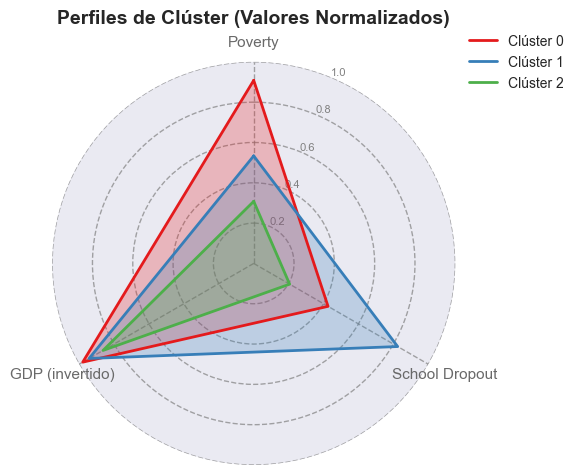

In [ ]:
# Preparar los datos
# Usaremos las medias de las variables para cada clúster.

features = ['poverty', 'school_dropout', 'gdp']
cluster_means = df_imputed.groupby('cluster')[features].mean()

# 2. Normalizar los datos para el radar chart (Min-Max Scaling 0-1)
# IMPORTANTE: Normalizar entre el MIN y MAX global de cada característica para todos los clústeres
data_for_radar = cluster_means.copy()
for feature in features:
    min_val = df_imputed[feature].min()
    max_val = df_imputed[feature].max()
    data_for_radar[feature] = (cluster_means[feature] - min_val) / (max_val - min_val)

data_for_radar['gdp'] = 1 - data_for_radar['gdp']

# Radar Chart
# Número de variables (ejes)
num_vars = len(features)

# Calcular el ángulo para cada eje
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1] # Cierra el círculo

# Para cada clúster, creamos una lista de valores y la cerramos
cluster_data_plots = {}
for idx, row in data_for_radar.iterrows():
    values = row.tolist()
    values += values[:1] # Cierra el círculo
    cluster_data_plots[idx] = values

radar_labels = [col.replace('_', ' ').title() for col in features]
# Cambiar la etiqueta de GDP si existe
for i, label in enumerate(radar_labels):
    if label.lower() == 'gdp':
        radar_labels[i] = 'GDP (invertido)'
        break


fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

# Configurar color de la grilla (líneas radiales y circulares)
ax.yaxis.grid(True, color='gray', linestyle='--', linewidth=1, alpha=0.7) # Líneas circulares
ax.xaxis.grid(True, color='gray', linestyle='--', linewidth=1, alpha=0.7) # Líneas radiales

# Aumentar la visibilidad de las etiquetas de los ejes
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], color="dimgray", size=9)
ax.tick_params(axis='x', colors='dimgray', labelsize=11)

# Dibujar cada clúster en el radar chart
colors = sns.color_palette("Set1", n_colors=k_optimo)

for i in range(k_optimo):
    ax.plot(angles, cluster_data_plots[i], linewidth=2, linestyle='solid', label=f'Clúster {i}', color=colors[i])
    ax.fill(angles, cluster_data_plots[i], color=colors[i], alpha=0.25) # Rellenar el área

# Configuración del gráfico
ax.set_theta_offset(np.pi / 2) # Rotar el inicio del eje a la parte superior
ax.set_theta_direction(-1) # Sentido de las agujas del reloj

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels)

# Establecer límites de y para que el 0 esté en el centro y 1 en el exterior
ax.set_ylim(0, 1) # Ya que hemos normalizado a 0-1
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], color="grey", size=8)

ax.set_title('Perfiles de Clúster (Valores Normalizados)', va='bottom', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()


---
---
# Visualizaciones Avanzadas

### Viz 3D
 - GDP vs. Poverty vs. School Dropout

In [ ]:
import plotly.express as px
import plotly.io as pio

# Configuración de Plotly para visualización en navegador (o en el notebook)
# pio.renderers.default = 'browser' # Abre el gráfico en una nueva pestaña del navegador
pio.renderers.default = 'notebook_connected' # Muestra el gráfico incrustado en el notebook (si el entorno lo soporta)
                                            # Puedes probar 'browser' si 'notebook_connected' no funciona bien.


print("\n=== Creando Visualización 3D Interactiva con Plotly: GDP vs. Poverty vs. School Dropout ===")

# Crear el gráfico de dispersión 3D interactivo
fig = px.scatter_3d(df_imputed,
                    x='poverty',
                    y='school_dropout',
                    z='gdp',
                    color='cluster',       # Colorea los puntos por el clúster
                    symbol='cluster',      # Usa diferentes símbolos por clúster (opcional)
                    size='gdp',            # Ajusta el tamaño de los puntos según el GDP (opcional, para resaltar provincias más grandes)
                    hover_name=df_imputed.index, # Muestra el nombre de la provincia al pasar el ratón (asumiendo que el índice es el nombre)
                    hover_data={           # Datos adicionales a mostrar al pasar el ratón
                        'poverty': ':.2f',
                        'school_dropout': ':.2f',
                        'gdp': ':, .0f'
                    },
                    title='Relación 3D Interactiva: GDP vs. Poverty vs. School Dropout por Clúster',
                    labels={               # Etiquetas para los ejes y la leyenda
                        'poverty': 'Pobreza (%)',
                        'school_dropout': 'Deserción Escolar (%)',
                        'gdp': 'GDP (Millones de Pesos)' # Ajusta la unidad según tu dataset
                    },
                    height=700             # Altura del gráfico en píxeles
                   )

# Ajustar el diseño del gráfico (opcional)
fig.update_layout(scene_camera=dict(eye=dict(x=1.5, y=1.5, z=0.5)), # Ángulo inicial de la cámara
                  margin=dict(l=0, r=0, b=0, t=50)) # Márgenes para el diseño

fig.show()


=== Creando Visualización 3D Interactiva con Plotly: GDP vs. Poverty vs. School Dropout ===


---
---
# FIN